# Trajectory Tangling Analysis — topographic RNN

Replicates Amengual et al. tangling analysis (Russo et al., 2018 method)
on the topographic checkpoint (`stage2_topo.pt`, `BioLeakyRNNTopo`, 144 units).

**Paper anchors (FEF recordings):**
- Pre-target: tangling has inverted-U shape vs CTOA (quadratic R²=0.72, p=0.0017)
- Post-target: tangling decreases monotonically with CTOA (linear R²=0.97, p≈0)
- Post-target tangling correlates with RT: Spearman ρ=0.63, p<0.04
- Pre-target tangling correlates with position info: Spearman ρ=0.7, p<0.032


In [1]:
import sys

sys.path.insert(0, "..")

import numpy as np
from collections import defaultdict
import torch
import matplotlib.pyplot as plt

from src.model_topo import BioLeakyRNNTopo
from src.env import CuedTargetWithDistractorsV3
from src.analysis import (
    collect_trials,
    tangling_by_ctoa_bin,
    polynomial_regression,
)
from src.plotting import (
    plot_tangling_timecourses,
    plot_tangling_vs_ctoa,
    plot_tangling_vs_rt,
)

device = "cpu"
print("device:", device)

device: cpu


## 1. Load model and collect trials

In [2]:
from pathlib import Path

ckpt_path = Path("../checkpoints/stage2_topo.pt")
assert ckpt_path.exists(), f"topo checkpoint not found: {ckpt_path}"


def make_model():
    return BioLeakyRNNTopo(
        input_size=7,
        hidden_size=180,
        output_size=2,
        dt=20.0,
        tau=100.0,
        activation="softplus",
        sigma_rec=0.10,
        rec_init="diag",
        use_ei=True,
        exc_ratio=0.80,
        use_dale=True,
        mask_seed=42,
        sheet_side=12,
        tau_ee=0.25,
        tau_ie=0.32,
        tau_ei=0.64,
        tau_ii=0.64,
        rf_sigma=0.3,
    )


def make_env():
    return CuedTargetWithDistractorsV3(
        dt=20,
        cue_strength=1.0,
        p_distractor_trial=0.6,
        distractor_strength=1.0,
        continuous_locations=True,
    )


model = make_model().to(device)
model.load_state_dict(
    torch.load(str(ckpt_path), map_location=device, weights_only=True)["state_dict"],
    strict=False,
)
model.eval()
model.noise_at_eval = True
print(f"Loaded {ckpt_path.name}, noise_at_eval={model.noise_at_eval}")

Loaded stage2_topo.pt, noise_at_eval=True


In [3]:
print("Collecting 2000 trials...")
trials = collect_trials(model, make_env, n_trials=2000, device=device)

outcomes = {}
for tr in trials:
    outcomes[tr["train_outcome"]] = outcomes.get(tr["train_outcome"], 0) + 1
print("Outcomes:", outcomes)

Outcomes: {'correct': 1592, 'abort': 327, 'false_alarm': 51, 'miss': 30}


## 2. Compute tangling

Windows aligned to target onset:
- **Pre-target**: −300..0 ms (steps −15..0)
- **Post-target**: 0..+600 ms (steps 0..+30)

PCA pre-reduction to 20D before computing tangling (reduces noise, speeds up computation).

In [4]:
# Pre-target window: -300..0 ms
tang_pre = tangling_by_ctoa_bin(
    trials,
    align_key="target_onset",
    window_before=15,  # 300 ms
    window_after=0,
    pca_dims=20,
    outcome="correct",
    min_trials=10,
)

# Post-target window: 0..+600 ms
tang_post = tangling_by_ctoa_bin(
    trials,
    align_key="target_onset",
    window_before=0,
    window_after=30,  # 600 ms
    pca_dims=20,
    outcome="correct",
    min_trials=10,
)

print(
    f'Pre-target  bins: {tang_pre["labels"]}  Q_mean: {np.round(tang_pre["Q_mean"], 4)}'
)
print(
    f'Post-target bins: {tang_post["labels"]}  Q_mean: {np.round(tang_post["Q_mean"], 4)}'
)

Pre-target  bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  Q_mean: [0.0159 0.014  0.0215 0.0214 0.0422 0.042  0.068  0.0834 0.1029 0.1296]
Post-target bins: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  Q_mean: [0.0158 0.0287 0.0255 0.0347 0.0383 0.0441 0.0531 0.0598 0.061  0.0663]


## 3. Tangling time courses per CTOA bin

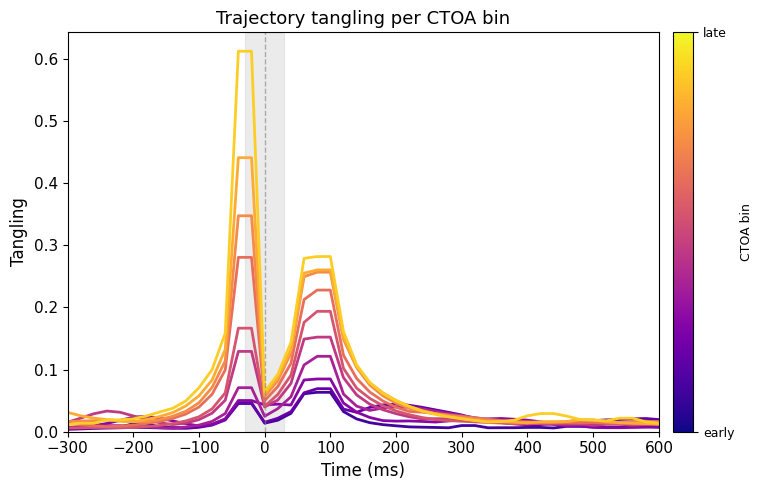

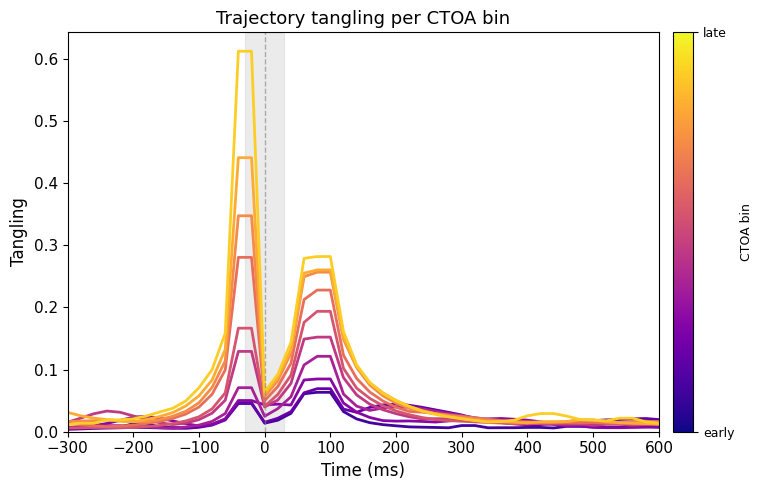

In [5]:
# Combined pre + post window in one figure, matching paper Figure 7A
plot_tangling_timecourses(tang_pre, tang_post, align_label="target_onset")

## 4. Tangling vs CTOA regression

Paper:
- Pre-target: **quadratic** fit R²=0.72, p=0.0017 (inverted-U shape)
- Post-target: **linear** fit R²=0.97, p≈0 (monotone decrease)

Pre-target:  R²=0.991  p=0.0000  (deg 2)
Post-target: R²=0.976  p=0.0000  (deg 1)


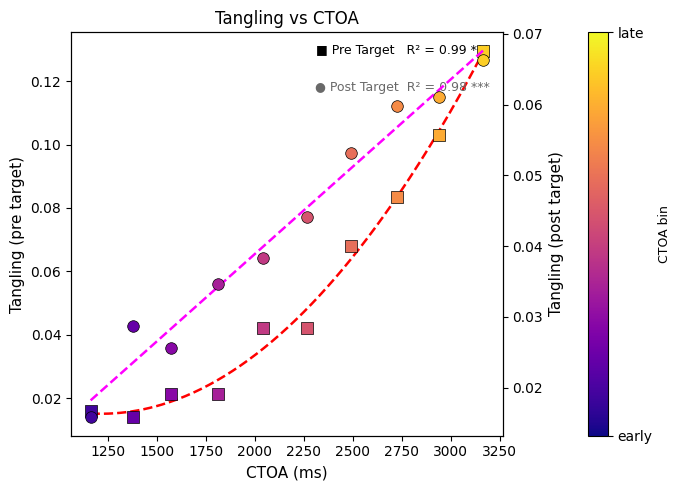

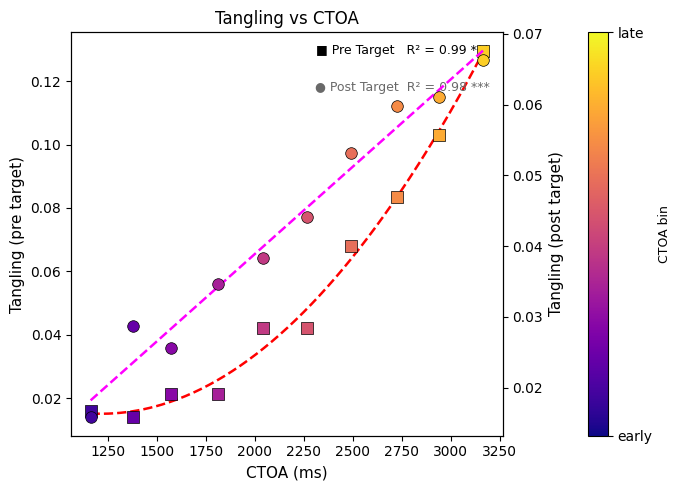

In [6]:
plot_tangling_vs_ctoa(tang_pre, tang_post)

In [7]:
# Also compare linear vs quadratic for pre-target (AIC comparison)
x = tang_pre["ctoa_ms_mean"]
y = tang_pre["Q_mean"]

for deg in [1, 2]:
    reg = polynomial_regression(x, y, degree=deg)
    n = len(x)
    k = deg + 1  # number of parameters incl. intercept
    ss_res = (
        np.sum((reg["y"] - reg["y_hat"]) ** 2) if reg["y_hat"] is not None else np.nan
    )
    # AIC = n*log(ss_res/n) + 2k
    aic = n * np.log(ss_res / n) + 2 * k if np.isfinite(ss_res) and ss_res > 0 else np.nan
    print(
        f'Pre-target deg-{deg}: R²={reg["r2"]:.3f}  p={reg["p_value"]:.4f}  AIC={aic:.1f}'
    )

Pre-target deg-1: R²=0.912  p=0.0000  AIC=-85.6
Pre-target deg-2: R²=0.991  p=0.0000  AIC=-106.4


## 5. Post-target tangling vs RT

Paper: Spearman ρ=0.63, p<0.04 — longer CTOA → less tangling → faster RT.

In [8]:
rt_by_bin = defaultdict(list)
for tr in trials:
    if tr["train_outcome"] == "correct" and tr.get("rt_ms") is not None:
        b = tr.get("ctoa_bin")
        if b is not None:
            rt_by_bin[b].append(tr["rt_ms"])

rt_mean = {b: np.mean(v) for b, v in rt_by_bin.items()}
print("Mean RT per CTOA bin (ms):")
for b in sorted(rt_mean):
    print(f"  bin {b}: {rt_mean[b]:.1f} ms  (n={len(rt_by_bin[b])})")

Mean RT per CTOA bin (ms):
  bin 0: 330.0 ms  (n=20)
  bin 1: 288.5 ms  (n=71)
  bin 2: 257.1 ms  (n=138)
  bin 3: 235.6 ms  (n=193)
  bin 4: 230.3 ms  (n=233)
  bin 5: 211.1 ms  (n=230)
  bin 6: 205.0 ms  (n=239)
  bin 7: 198.0 ms  (n=235)
  bin 8: 195.7 ms  (n=168)
  bin 9: 192.3 ms  (n=65)


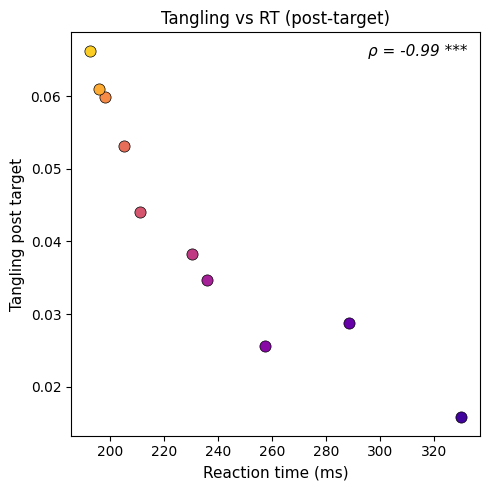

Spearman rho=-0.988  p=0.0000


In [9]:
fig, rho, p = plot_tangling_vs_rt(tang_post, rt_mean)

## 6. RT vs CTOA

Mean reaction time as a function of CTOA (correct trials only).

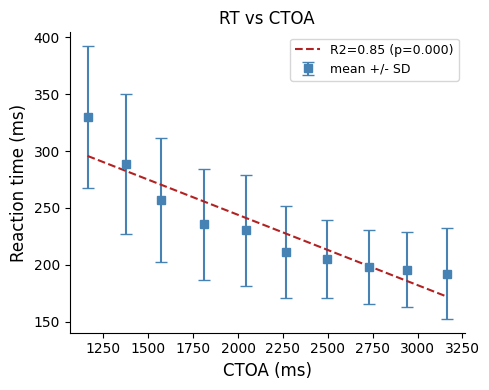

Linear regression: R2=0.852  slope=-0.0618 ms/ms  p=0.0001


In [10]:
# RT vs CTOA — linear regression + error bars (cf. paper Figure 5)
from scipy import stats as sp_stats
import numpy as np

bins = tang_post["labels"]
ctoa_x = tang_post["ctoa_ms_mean"]
rt_y = np.array([np.mean(rt_by_bin[b]) for b in bins])
rt_err = np.array([np.std(rt_by_bin[b], ddof=1) for b in bins])

slope, intercept, r, p_val, _ = sp_stats.linregress(ctoa_x, rt_y)
r2 = r**2
x_fit = np.linspace(ctoa_x.min(), ctoa_x.max(), 200)
y_fit = slope * x_fit + intercept

fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(
    ctoa_x,
    rt_y,
    yerr=rt_err,
    fmt="s",
    color="steelblue",
    capsize=4,
    linewidth=1.5,
    markersize=6,
    label="mean +/- SD",
)
ax.plot(
    x_fit,
    y_fit,
    "--",
    color="firebrick",
    linewidth=1.5,
    label="R2=%.2f (p=%.3f)" % (r2, p_val),
)
ax.set_xlabel("CTOA (ms)", fontsize=12)
ax.set_ylabel("Reaction time (ms)", fontsize=12)
ax.set_title("RT vs CTOA", fontsize=12)
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("Linear regression: R2=%.3f  slope=%.4f ms/ms  p=%.4f" % (r2, slope, p_val))

## Summary

| Metric | Paper | Model |
|--------|-------|-------|
| Pre-target: quadratic R² | 0.72 | ? |
| Pre-target: quadratic p | 0.0017 | ? |
| Post-target: linear R² | 0.97 | ? |
| Post-target: linear p | ~0 | ? |
| Tangling vs RT: Spearman ρ | 0.63 | ? |
| Tangling vs RT: p | <0.04 | ? |

Fill in '?' from outputs above.

> **Note:** Tangling vs position info (Spearman ρ=0.7) requires decoding accuracy per CTOA bin — see `05_decoding.ipynb`.